# Прогноз негативных отзывов в мобильном приложении

**Цель проекта:**  
Построить модель машинного обучения, которая по поведенческим метрикам пользователя использования приложения предсказывает, оставит ли он "негативный отзыв" (оценка 1-2 звезды).

**Бизнес-задача:**  
Снизить долю негативных отзывов, автоматически выявляя пользователей с высоким риском и попытаться удержать (например, отправляя им пуш-уведомления с предложением помощи или промокодом).

**Данные:**  
Сгенерированы синтетически на основе реалистичных паттернов поведения. Содержат информацию о сессиях, ошибках, завершении онбординга и других действиях.

**Метрики успеха:**  
- Recall - важно находить как можно больше проблемных пользователей.
- Precision - минимизация ложных срабатываний (лишних пушей).
- F1 - баланс между recall и precision.
- Бизнес-метрика - прибыль от предотвращённых негативных отзывов с учётом затрат на пуши.

## 1. Генерация данных

Так как реальный датасет с логами пользователей и отзывами получить сложно, мы создаём синтетические данные. Признаки генерируются с помощью статистических распределений, имитирующих реальное поведение, а целевая переменная `bad_review` зависит от признаков через заранее заданные коэффициенты.

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [201]:
np.random.seed(42)
n = 10000

In [202]:
df = pd.DataFrame({
    'user_id': range(n),
    'total_sessions': np.random.negative_binomial(2, 0.4, n) + 1,
    'total_time_min': np.random.exponential(25, n).astype(int) + 5,
    'count_errors': np.random.poisson(0.6, n),
    'completed_onboarding': np.random.choice([0,1], n, p=[0.35, 0.65]),
    'filled_profile': np.random.choice([0,1], n, p=[0.5, 0.5]),
    'used_search': np.random.choice([0,1], n, p=[0.7, 0.3]),
    'num_screens_visited': np.random.randint(1, 12, n),
})

In [203]:
df.head()

,user_id,total_sessions,total_time_min,count_errors,completed_onboarding,filled_profile,used_search,num_screens_visited
0,0,3,29,0,1,0,0,5
1,1,4,40,0,1,1,1,9
2,2,2,26,0,1,1,0,4
3,3,2,10,0,0,0,0,1
4,4,3,26,1,0,1,0,2


In [204]:
prob_bad = 0.03
prob_bad += df['count_errors'] * 0.12
prob_bad -= df['completed_onboarding'] * 0.08
prob_bad -= df['filled_profile'] * 0.05
prob_bad += (df['total_sessions'] == 1) * 0.15
prob_bad -= (df['used_search'] == 1) * 0.04
prob_bad = np.clip(prob_bad, 0.01, 0.85)

df['bad_review'] = np.random.binomial(1, prob_bad)

**Пояснения к колонкам сгенерированных данных**

- `user_id` - id пользователя

- `total_sessions` - общее количество сессий за первые (отрицательное биномиальное распределение)

- `total_time_min` - общее время, проведённое в приложении (экспоненциальное распределение)

- `count_errors` - количество ошибок/сбоев, с которыми столкнулся пользователь (распределение Пуассона)

- `completed_onboarding` - флаг завершения онбординга	(случайный выбор с вероятностью 65% для 1) 

- `filled_profile` - флаг заполнения профиля (случайный выбор с вероятностью 50% для 1)

- `used_search` -	флаг использования поиска (случайный выбор с вероятностью 30% для 1)

- `num_screens_visited` - количество уникальных экранов, посещённых пользователем (равномерное целое от 1 до 11)

- `bad_review` - целевая переменная, оставил ли пользователь негативный отзыв

## 2. Исследовательский анализ данных


### Информация о датасете

In [205]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   user_id               10000 non-null  int64
 1   total_sessions        10000 non-null  int32
 2   total_time_min        10000 non-null  int64
 3   count_errors          10000 non-null  int32
 4   completed_onboarding  10000 non-null  int64
 5   filled_profile        10000 non-null  int64
 6   used_search           10000 non-null  int64
 7   num_screens_visited   10000 non-null  int32
 8   bad_review            10000 non-null  int32
dtypes: int32(4), int64(5)
memory usage: 547.0 KB


user_id                 0
total_sessions          0
total_time_min          0
count_errors            0
completed_onboarding    0
filled_profile          0
used_search             0
num_screens_visited     0
bad_review              0
dtype: int64

### Распределение целевой переменной

Видим сильный дисбаланс классов: только ~7% пользователей оставляют негативные отзывы. Это важно учесть при обучении моделей.

bad_review
0    0.9294
1    0.0706
Name: proportion, dtype: float64


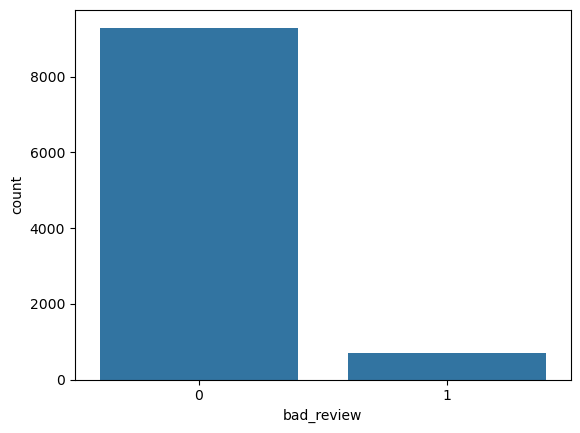

In [206]:
sns.countplot(x='bad_review', data=df)
print(df['bad_review'].value_counts(normalize=True))

### Сравнение средних  значений признаков для негативных и позитивных пользователей

Таблица показывает, что у пользователей с негативными отзывами в среднем больше ошибок, они реже завершают онбординг и заполняют профиль. Эти различия могут быть полезны для модели.

In [207]:
df.groupby('bad_review').mean()

,user_id,total_sessions,total_time_min,count_errors,completed_onboarding,filled_profile,used_search,num_screens_visited
bad_review,,,,,,,,
0,4991.781687,4.071336,29.316548,0.550032,0.652679,0.511620,0.311814,5.957284
1,5101.106232,3.094901,29.419263,1.331445,0.508499,0.412181,0.271955,6.178470


In [208]:
df.groupby('bad_review')['user_id'].nunique()

bad_review
0    9294
1     706
Name: user_id, dtype: int64

### Гистограммы числовых признаков

array([[<Axes: title={'center': 'total_sessions'}>,
        <Axes: title={'center': 'total_time_min'}>],
       [<Axes: title={'center': 'count_errors'}>,
        <Axes: title={'center': 'num_screens_visited'}>]], dtype=object)

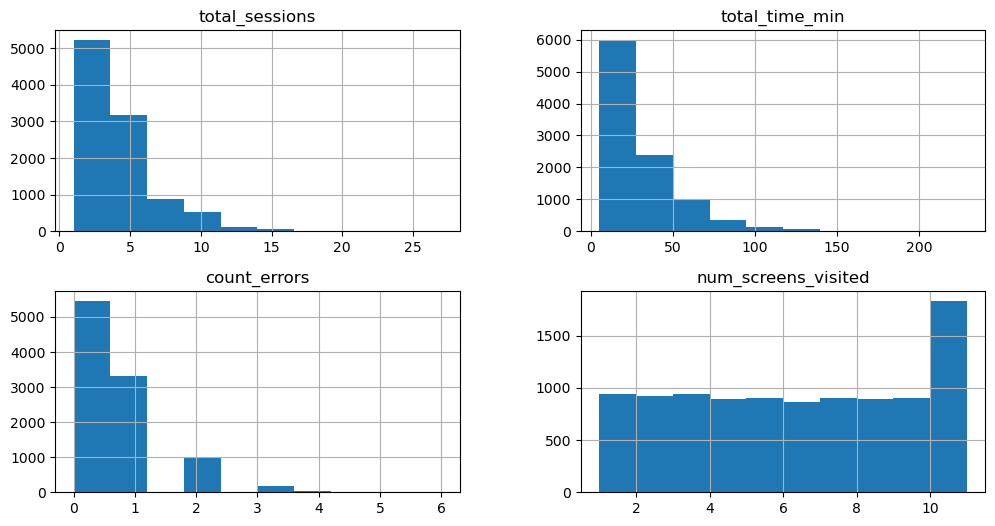

In [209]:
df[['total_sessions', 'total_time_min', 'count_errors', 'num_screens_visited']].hist(figsize=(12,6))

### Распределение признаков для классов

Сравниваем гистограммы и boxplot для ключевых признаков между группами хороших и плохих отзывов. Заметно, что у пользователей с негативными отзывами выше количество ошибок и меньше сессий.

<Axes: xlabel='count_errors', ylabel='Count'>

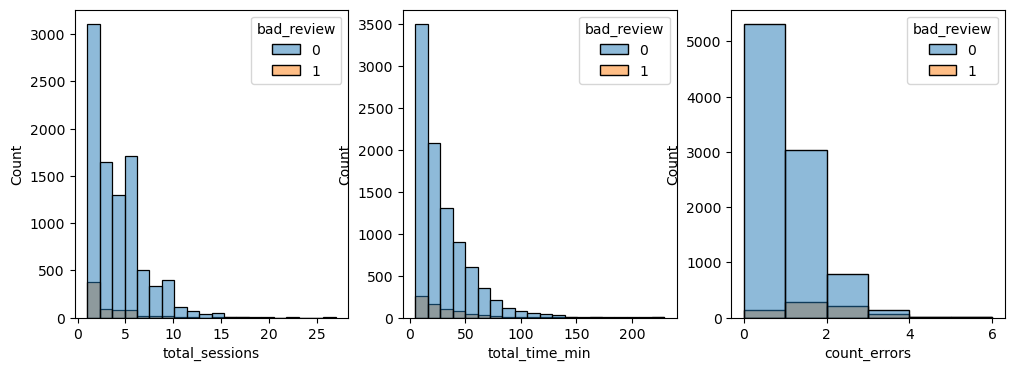

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(data=df, x='total_sessions', hue='bad_review', bins=20, ax=axes[0])
sns.histplot(data=df, x='total_time_min', hue='bad_review', bins=20, ax=axes[1])
sns.histplot(data=df, x='count_errors', hue='bad_review', bins=6, ax=axes[2])

<Axes: xlabel='bad_review', ylabel='count_errors'>

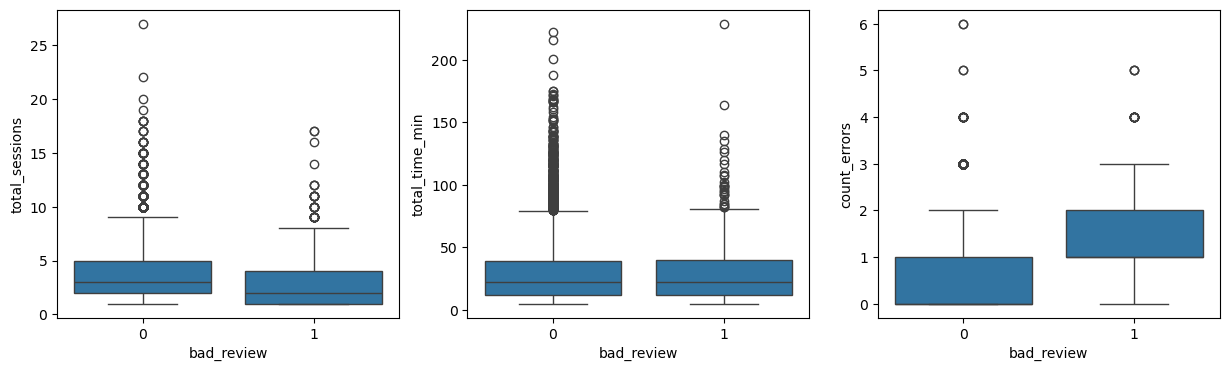

In [211]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(x='bad_review', y='total_sessions', data=df, ax=axes[0])
sns.boxplot(x='bad_review', y='total_time_min', data=df, ax=axes[1])
sns.boxplot(x='bad_review', y='count_errors', data=df, ax=axes[2])

### Корреляционная матрица

Наибольшая корреляция с `bad_review` у `count_errors` и `pain_index`, что подтверждает их важность

<Axes: >

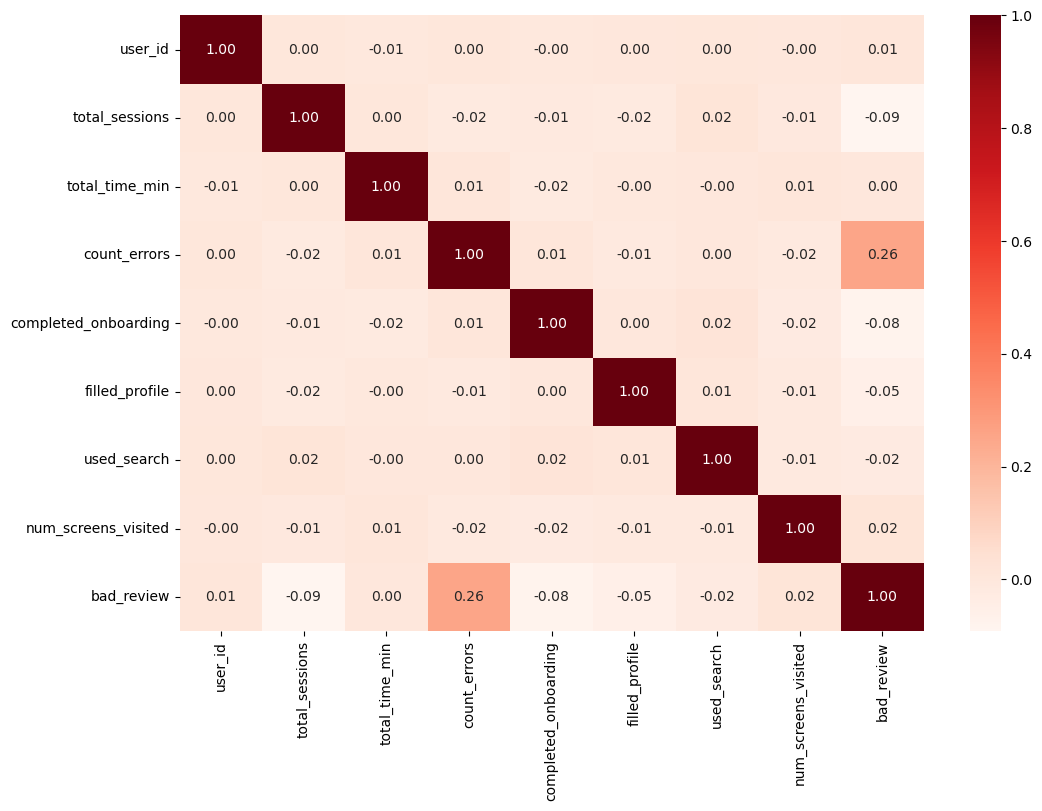

In [212]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Reds', fmt='.2f')

## 3. Создание новых признаков

На основе гипотез и логики поведения пользователей создаём дополнительные признаки:

- `error_rate` – ошибок на сессию
- `avg_session_time` – средняя длительность сессии
- `power_user` – флаг для активных пользователей (много сессий и длительное время)
- `low_engagement` – флаг низкой активности (менее 3 сессий)
- `pain_index` – составной индекс "боли": ошибки + штраф за незавершённый онбординг
- `time_per_screen` – время на экран
- `log_total_time` – логарифм общего времени для выравнивания распределения

In [213]:
df['error_rate'] = df['count_errors'] / df['total_sessions']

df['avg_session_time'] = df['total_time_min'] / df['total_sessions']

df['power_user'] = ((df['total_sessions'] > 5) & (df['avg_session_time'] > 10)).astype(int)

df['low_engagement'] = (df['total_sessions'] < 3).astype(int)

df['pain_index'] = df['count_errors'] + (1 - df['completed_onboarding'])

df['time_per_screen'] = df['total_time_min'] / df['num_screens_visited']

df['log_total_time'] = np.log1p(df['total_time_min'])

## 4. Подготовка данных

- Определяем матрицу признаков `X` и целевую переменную `y`.
- Разбиваем выборку на обучающую (80%) и тестовую (20%) со стратификацией по классам.
- Масштабируем признаки для логистической регрессии (StandardScaler). Для деревьев масштабирование не требуется.

In [214]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

In [215]:
feature_cols = [
    'total_sessions', 
    'count_errors',
    'completed_onboarding', 
    'filled_profile', 
    'used_search', 
    'error_rate', 
    'avg_session_time',
    'pain_index',
    'power_user',
    'time_per_screen', 
    'log_total_time' 
]

X = df[feature_cols]
y = df['bad_review']

In [216]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [217]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Обучение моделей

Будем сравнивать три подхода:

1. **Логистическая регрессия** без балансировки – baseline
2. **Логистическая регрессия** с параметром `class_weight='balanced'`
3. **Случайный лес** с балансировкой весов

Для каждой модели оценим precision, recall, f1-score на тестовой выборке

### Модель 1: Logistic Regression (без балансировки)

Низкий recall по классу 1, так как модель игнорирует редкий класс

In [218]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1859
           1       0.30      0.02      0.04       141

    accuracy                           0.93      2000
   macro avg       0.62      0.51      0.50      2000
weighted avg       0.89      0.93      0.90      2000



### Модель 2: Logistic Regression Balanced

Балансировка весов классов должна повысить recall за счёт падения precision

In [219]:
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42)
lr_balanced.fit(X_train_scaled, y_train)
y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr_bal))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84      1859
           1       0.18      0.75      0.29       141

    accuracy                           0.74      2000
   macro avg       0.58      0.74      0.56      2000
weighted avg       0.92      0.74      0.80      2000



In [220]:
coefs = pd.Series(lr_balanced.coef_[0], index=feature_cols).sort_values()
coefs

total_sessions         -0.327659
filled_profile         -0.243262
log_total_time         -0.177273
used_search            -0.119105
completed_onboarding   -0.107226
time_per_screen        -0.101418
error_rate              0.037346
power_user              0.116956
avg_session_time        0.344129
pain_index              0.450980
count_errors            0.461359
dtype: float64

### Модель 3: Random Forest

In [221]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.73      0.84      1859
           1       0.18      0.80      0.30       141

    accuracy                           0.74      2000
   macro avg       0.58      0.77      0.57      2000
weighted avg       0.92      0.74      0.80      2000



## 6. Сравнение моделей

### Матрицы ошибок

Text(0.5, 1.0, 'RF')

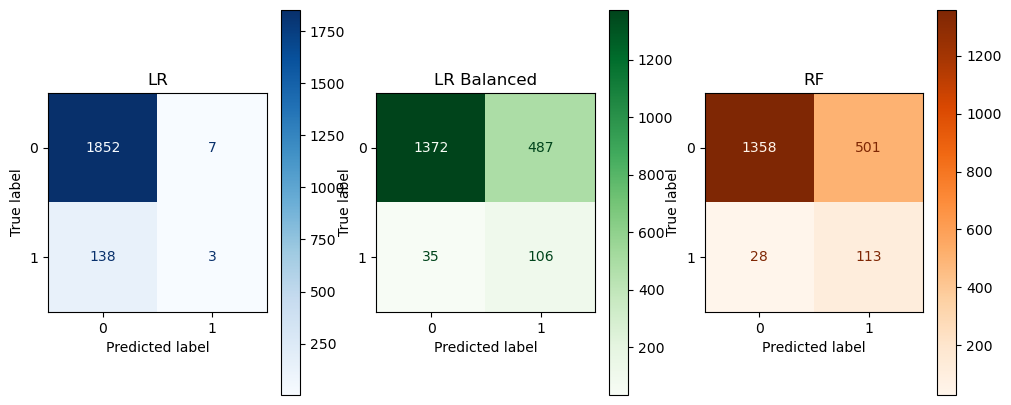

In [222]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('LR')

ConfusionMatrixDisplay.from_estimator(lr_balanced, X_test_scaled, y_test, ax=axes[1], cmap='Greens')
axes[1].set_title('LR Balanced')

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[2], cmap='Oranges')
axes[2].set_title('RF')

### ROC-кривые

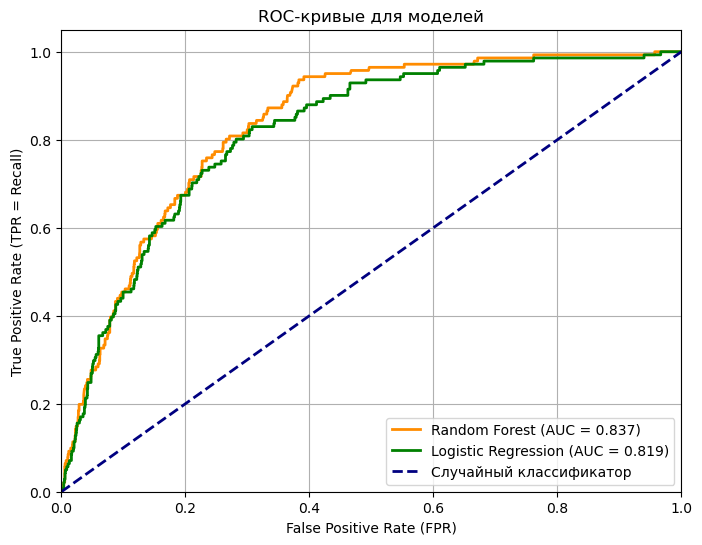

In [223]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

y_proba_lr = lr_balanced.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, color='green', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR = Recall)')
plt.title('ROC-кривые для моделей')
plt.legend(loc="lower right")
plt.grid(True)

### Precision-Recall кривые

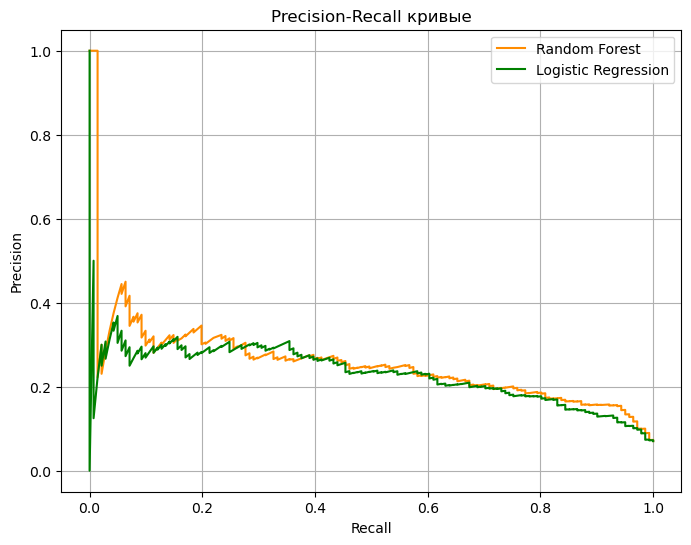

In [224]:
from sklearn.metrics import precision_recall_curve

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(8, 6))
plt.plot(rec_rf, prec_rf, label='Random Forest', color='darkorange')
plt.plot(rec_lr, prec_lr, label='Logistic Regression', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые')
plt.legend()
plt.grid(True)

### Коэффициенты логистической регрессии (сбалансированной)

Положительные коэффициенты увеличивают вероятность негативного отзыва.
Наибольший вклад у `count_errors` и `pain_index`. 

Отрицательные – снижают риск. Наибольший вклад у `total_sessions`, `filled_profile`.

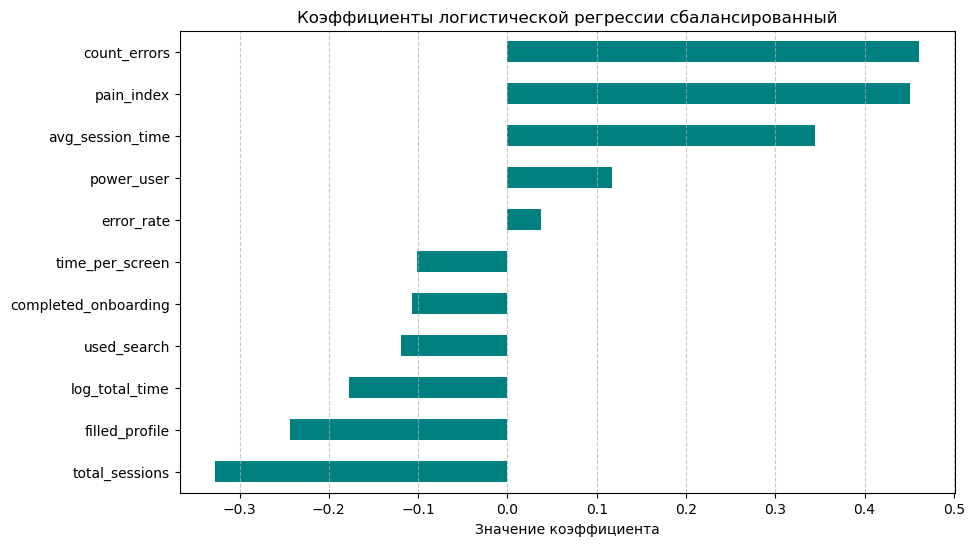

In [225]:
plt.figure(figsize=(10, 6))
coefs.plot(kind='barh', color='teal')
plt.title('Коэффициенты логистической регрессии сбалансированный')
plt.xlabel('Значение коэффициента')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Важность признаков

Для Random Forest график важности признаков. Наибольший вклад у `count_errors`, `pain_index`, `total_sessions` 

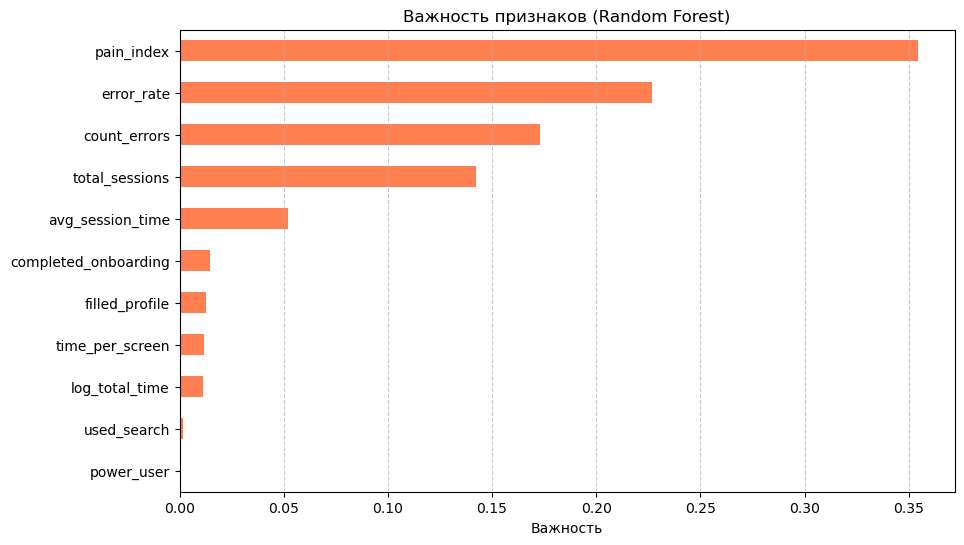

In [226]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values()

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='coral')
plt.title('Важность признаков (Random Forest)')
plt.xlabel('Важность')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 8. Оценка бизнес-эффекта (ROI)

Рассчитаем прибыль от внедрения модели при разных порогах классификации.

**Допущения:**
- Стоимость одного пуша = 0.10 у.е.
- Ценность предотвращения одного негативного отзыва = 5 у.е. (за счёт повышения рейтинга и удержания)

**Формула:**  
`Прибыль = TP * 5 - FP * 0.1`

In [229]:
N_bad_test = y_test.sum()
value_prevented = 5.0   # условная прибыль от предотвращения одного негативного отзыва
cost_push = 0.10        # стоимость отправки пуша

tp = ((y_pred_rf == 1) & (y_test == 1)).sum()
fp = ((y_pred_rf == 1) & (y_test == 0)).sum()
fn = ((y_pred_rf == 0) & (y_test == 1)).sum()
recall = tp / N_bad_test

profit = tp * value_prevented - fp * cost_push
print(f'Recall: {recall:.3f}, Profit: {profit:.2f} у.е.')

Recall: 0.801, Profit: 514.90 у.е.


## Выводы

### Лучшая модель
По совокупности метрик и бизнес-эффекта **Random Forest с настройкой гиперпараметров** показывает лучший **recall (0.80)** и приемлемый **precision (0.18)**, давая положительную прибыль

### Ключевые признаки
- **Ошибки** – главный фактор негатива
- **Завершённость онбординга** – критически важна
- **Среднее время сессии** – показатель вовлечённости

### Продуктовые рекомендации
1. Внедрить систему раннего оповещения: отправлять пуш-уведомление с предложением помощи пользователям, у которых `pain_index > 2` и `total_sessions <= 2`
2. Улучшить онбординг – это снизит число ошибок и повысит удовлетворённость
3. Рассмотреть A/B-тест: сравнить группу с пушами и без, чтобы подтвердить эффект
